**Laboratorio 4: Multimodal**

**Estudiante: Juan De Dios Sullca Rodriguez**

**Materia: Inteligencia Artificial I**

**Dataset: Conjunto de datos de deriva de la matriz de sensores de gas**

**Descripcion del data set:  Este archivo contiene 13910 mediciones de 16 sensores químicos utilizados en simulaciones para la compensación de deriva en una tarea de discriminación de 6 gases a varios niveles de concentración**

**IMPORTACIÓN DE LIBRERÍAS Y DEPENDENCIAS**

Para el desarrollo de este modelo, inicializamos el entorno importando las herramientas fundamentales agrupadas según su función técnica:

Manejo de archivos: Utilizamos os y glob para la búsqueda y lectura automatizada de los lotes de datos en el directorio.

Procesamiento matemático y estructuración: Implementamos numpy para el cálculo matricial avanzado y pandas para la manipulación y preprocesamiento del dataset.

Carga de datos y métricas: Empleamos utilidades de scikit-learn (sklearn) para importar el formato de datos dispersos (SVMLight) y para evaluar la efectividad final mediante la matriz de confusión.

Visualización: Integramos matplotlib y seaborn para generar las curvas de aprendizaje, el mapa de calor y la representación visual de la huella química de los gases.

In [11]:
import os
import glob
import numpy as np
import pandas as pd
from sklearn.datasets import load_svmlight_file
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

**montar driva al colab**

In [12]:
from google.colab import drive
drive.mount('/content/gdrive')

Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).


**INTEGRACIÓN, CARGA DE DATOS Y ESTRUCTURACIÓN CON PANDAS**

En esta fase inicial  procedimos a la recolección, decodificación y consolidación de la información proveniente de los sensores de gases. Dado que el dataset original estaba fragmentado, implementamos un proceso automatizado para unificar las mediciones.

Localización y Extracción por Lotes: Utilizamos la librería glob para rastrear y localizar automáticamente los 10 archivos con extensión .dat alojados en el directorio del proyecto. Esto nos permitió procesar el dataset completo sin necesidad de cargar cada archivo manualmente.

Decodificación y Ensamblaje Matricial: Los datos originales se encontraban en formato SVMLight (un formato optimizado para matrices dispersas). Para interpretar esta información, utilizamos la herramienta load_svmlight_file, la cual extrae las características y las etiquetas de cada lote. Posteriormente, convertimos estas estructuras en matrices densas y aplicamos una concatenación vertical (np.vstack) para fusionar todos los lotes en una única matriz global de características (X_raw) y un solo vector de etiquetas (y_raw).

Estructuración en Pandas y Análisis Exploratorio: Cumpliendo con los requerimientos técnicos establecidos para el preprocesamiento, migramos toda la información consolidada a un DataFrame de Pandas. Generamos nombres secuenciales para las 128 columnas (correspondientes a los 128 sensores) y añadimos la columna objetivo (target). Finalmente, ejecutamos una inspección inicial de las dimensiones de la matriz y de la distribución de las clases, lo que nos permitió evidenciar el desbalance original de los datos y justificar la necesidad del proceso de balanceo posterior.

In [13]:
# 1. Ruta a la carpeta con los 10 archivos .dat
ruta_carpeta = "/content/gdrive/MyDrive/Inteligencia Artificial I (SIS 420)/Laboratorios/LAB 4/gases/"
archivos = glob.glob(ruta_carpeta + "*.dat")
print(f"Se encontraron {len(archivos)} archivos .dat para procesar.\n")

# 2. Cargar y unir todos los archivos
X_list = []
y_list = []
for archivo in archivos:
    X_batch, y_batch = load_svmlight_file(archivo)
    X_list.append(X_batch.toarray())
    y_list.append(y_batch)

X_raw = np.vstack(X_list)
y_raw = np.concatenate(y_list)

# 3. USO DE PANDAS PARA PREPROCESAMIENTO (Regla del profesor)
# Convertimos la matriz X y el vector y en un solo DataFrame de Pandas
columnas = [f"caracteristica_{i}" for i in range(1, X_raw.shape[1] + 1)]
df = pd.DataFrame(X_raw, columns=columnas)
df['target'] = y_raw

print("--- DIMENSIONES DEL DATASET ---")
print(f"Filas (m): {df.shape[0]}, Columnas (n + 1): {df.shape[1]}\n")

print("--- DISTRIBUCIÓN DE CLASES ANTES DE BALANCEAR ---")
# Contamos cuántos ejemplos hay de cada gas
distribucion = df['target'].value_counts().sort_index()
print(distribucion)

Se encontraron 10 archivos .dat para procesar.

--- DIMENSIONES DEL DATASET ---
Filas (m): 13910, Columnas (n + 1): 129

--- DISTRIBUCIÓN DE CLASES ANTES DE BALANCEAR ---
target
1.0    2565
2.0    2926
3.0    1641
4.0    1936
5.0    3009
6.0    1833
Name: count, dtype: int64


**PREPROCESAMIENTO: BALANCEO, PARTICIÓN Y NORMALIZACIÓN DE DATOS**

En esta etapa procedimos a preparar los datos crudos para garantizar que el modelo matemático pueda procesar la información de los sensores de manera óptima, evitando sesgos y problemas de convergencia durante el entrenamiento.Balanceo de Clases (Undersampling): Al analizar la distribución original de los gases, detectamos que las clases estaban desequilibradas. Para solucionar esto, identificamos la clase con la menor cantidad de registros (1641 ejemplos) y realizamos un submuestreo aleatorio del resto de las categorías para igualar esta cantidad. Esto asegura que el dataset quede perfectamente equilibrado y evita que el algoritmo desarrolle un sesgo predictivo hacia los gases más frecuentes. Finalmente, mezclamos todas las filas de forma aleatoria para romper cualquier orden secuencial que pudiera afectar el aprendizaje.Partición de Datos (Hold-out 80/20): Dividimos el conjunto balanceado en dos matrices completamente aisladas. Asignamos el 80% de los ejemplos para la fase de entrenamiento y reservamos estrictamente el 20% restante para la fase de pruebas. Esta separación garantiza que la evaluación final del modelo se realice con información que jamás ha visto, validando así su capacidad real de generalización frente a nuevos olores químicos.Normalización de Características (Z-score): Dado que estamos trabajando con 128 sensores que pueden tener rangos de lectura muy distintos, implementamos una función para estandarizar las escalas y asegurar que el Descenso por el Gradiente funcione de manera eficiente. Calculamos la media ($\mu$) y la desviación estándar ($\sigma$) únicamente utilizando los datos de entrenamiento. Esto es un paso crítico para evitar la fuga de información (data leakage). Posteriormente, aplicamos estos mismos valores de escalado al conjunto de prueba. Además, incorporamos un mecanismo de seguridad algorítmica para evitar divisiones por cero en el caso de que algún sensor presentara un valor constante a lo largo de las mediciones.

In [14]:
# 1. Encontrar el número mínimo de ejemplos (que es 1641)
min_ejemplos = df['target'].value_counts().min()

# 2. BALANCEO: Tomamos exactamente 'min_ejemplos' de cada clase aleatoriamente
df_balanceado = df.groupby('target').apply(lambda x: x.sample(min_ejemplos, random_state=42)).reset_index(drop=True)

# Mezclamos las filas para que no queden ordenadas (1,1.. 2,2.. etc)
df_balanceado = df_balanceado.sample(frac=1, random_state=42).reset_index(drop=True)

print("--- DISTRIBUCIÓN DE CLASES DESPUÉS DEL BALANCEO ---")
print(df_balanceado['target'].value_counts().sort_index())

# 3. Separar en matriz de características (X) y vector de etiquetas (y)
X_bal = df_balanceado.drop('target', axis=1).values
y_bal = df_balanceado['target'].values

# 4. PARTICIÓN 80/20
m_total = len(df_balanceado)
m_train = int(m_total * 0.8) # 80% para entrenar

# Cortamos los arreglos
X_train = X_bal[:m_train, :]
y_train = y_bal[:m_train]

X_test = X_bal[m_train:, :]
y_test = y_bal[m_train:]

print(f"\n--- PARTICIÓN DE DATOS (80/20) ---")
print(f"Total de datos balanceados: {m_total}")
print(f"Ejemplos para ENTRENAR (80%): {X_train.shape[0]}")
print(f"Ejemplos para PROBAR (20%): {X_test.shape[0]}")

# 5. NORMALIZACIÓN
def featureNormalize(X):
    mu = np.mean(X, axis=0)
    sigma = np.std(X, axis=0)
    sigma[sigma == 0] = 1  # Evitar división por cero si alguna columna es constante
    X_norm = (X - mu) / sigma
    return X_norm, mu, sigma

# Calculamos mu y sigma SOLO con los datos de entrenamiento
X_train_norm, mu, sigma = featureNormalize(X_train)

# Aplicamos ese mismo mu y sigma a los datos de prueba
X_test_norm = (X_test - mu) / sigma

print("\n¡Datos normalizados y listos para el modelo!")

--- DISTRIBUCIÓN DE CLASES DESPUÉS DEL BALANCEO ---
target
1.0    1641
2.0    1641
3.0    1641
4.0    1641
5.0    1641
6.0    1641
Name: count, dtype: int64

--- PARTICIÓN DE DATOS (80/20) ---
Total de datos balanceados: 9846
Ejemplos para ENTRENAR (80%): 7876
Ejemplos para PROBAR (20%): 1970

¡Datos normalizados y listos para el modelo!


/tmp/ipykernel_20186/1092228195.py:5: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_balanceado = df.groupby('target').apply(lambda x: x.sample(min_ejemplos, random_state=42)).reset_index(drop=True)


FUNCIONES MATEMÁTICAS Y ENTRENAMIENTO DEL MODELO
En esta sección desarrollamos el motor matemático del proyecto, donde se definen las ecuaciones fundamentales y se ejecuta el entrenamiento de los seis clasificadores para que aprendan a reconocer las firmas químicas de los distintos gases.

La Función Sigmoide y el Cálculo de Costo: Primero implementamos la función sigmoide, encargada de proyectar cualquier resultado lineal en una probabilidad real entre 0 y 1. Se le aplicó un límite de seguridad numérico para evitar desbordamientos de memoria con valores extremos. Luego, construimos la función de costo regularizada, que evalúa el margen de error del modelo. Aquí se añadió una protección algorítmica vital para evitar logaritmos de cero absolutos. La regularización es un paso esencial que obliga al modelo a generalizar los patrones de los 128 sensores en lugar de simplemente memorizar el dataset, teniendo la precaución de no penalizar el término de sesgo (bias).

Estrategia Uno Contra Todos (One-vs-All): Para abordar este problema multiclase, aplicamos la estrategia de dividir el problema entrenando seis modelos independientes. A través de un bucle iterativo, el problema se reduce temporalmente a una clasificación binaria: el modelo evalúa si la muestra pertenece a un gas específico (valor 1) o al resto de los gases (valor 0). Durante este proceso, el Descenso por el Gradiente ajusta los pesos iterativamente y almacena el historial del costo para analizar la convergencia.

Ejecución del Entrenamiento: Para inicializar el proceso, configuramos los hiperparámetros principales estableciendo el parámetro de regularización en 0.1 y la tasa de aprendizaje en 0.3. La clave metodológica en este punto es que el entrenamiento se alimenta única y exclusivamente con el 80% de los datos destinados a entrenamiento. De esta forma, se garantiza que el modelo no tenga contacto con los datos de prueba y su aprendizaje sea completamente legítimo.

In [15]:
# 1. Funciones Matemáticas
def calcularSigmoide(z):
    z = np.clip(z, -250, 250)
    return 1.0 / (1.0 + np.exp(-z))

def calcularCosto(theta, X, y, lambda_):
    m = len(y)
    h = calcularSigmoide(np.dot(X, theta))
    h = np.clip(h, 1e-15, 1 - 1e-15) # Evitar logaritmos de cero

    temp = theta.copy()
    temp[0] = 0 # No regularizamos el término de sesgo (bias)

    J = (1 / m) * np.sum(-y * np.log(h) - (1 - y) * np.log(1 - h)) + (lambda_ / (2 * m)) * np.sum(np.square(temp))
    grad = (1 / m) * np.dot(X.T, (h - y)) + (lambda_ / m) * temp

    return J, grad

# 2. Entrenamiento con Descenso por el Gradiente para guardar el historial
def oneVsAll_Gradiente(X, y, num_labels, lambda_, alpha, num_iters):
    m, n = X.shape
    all_theta = np.zeros((num_labels, n + 1))
    all_J_history = [] # Aquí guardaremos los costos para la gráfica

    # Agregar columna de unos a X
    X = np.concatenate([np.ones((m, 1)), X], axis=1)

    for c in range(1, num_labels + 1):
        theta = np.zeros(n + 1)
        y_c = (y == c).astype(int) # 1 si es la clase actual, 0 si no lo es
        J_history = np.zeros(num_iters)

        for i in range(num_iters):
            costo, grad = calcularCosto(theta, X, y_c, lambda_)
            theta = theta - alpha * grad
            J_history[i] = costo

        all_theta[c - 1, :] = theta
        all_J_history.append(J_history)
        print(f"Clasificador para la Clase {c} entrenado (Costo final: {costo:.4f})")

    return all_theta, all_J_history

# 3. Configurar parámetros y EJECUTAR el entrenamiento
lambda_ = 0.1
alpha = 0.3        # Tasa de aprendizaje
num_iters = 1000   # Iteraciones suficientes para ver cómo baja el costo
num_labels = 6     # 6 tipos de gases

print("Iniciando entrenamiento...")
# IMPORTANTE: Entrenamos SOLAMENTE con el 80% de los datos (X_train_norm)
all_theta, all_J_history = oneVsAll_Gradiente(X_train_norm, y_train, num_labels, lambda_, alpha, num_iters)

print("\n¡Entrenamiento completado!")

Iniciando entrenamiento...
Clasificador para la Clase 1 entrenado (Costo final: 0.0569)
Clasificador para la Clase 2 entrenado (Costo final: 0.0347)
Clasificador para la Clase 3 entrenado (Costo final: 0.0433)
Clasificador para la Clase 4 entrenado (Costo final: 0.2135)
Clasificador para la Clase 5 entrenado (Costo final: 0.0504)
Clasificador para la Clase 6 entrenado (Costo final: 0.0900)

¡Entrenamiento completado!


**PREDICCIONES FINALES Y GRAFICAS DE RENDIMIENTO**

aqui cerramos el ciclo de entrenamiento y pasamos a la fase de evaluacion creando la funcion maestra para hacer las predicciones
lo primero que hace esta funcion es agregar la columna de unos a los datos nuevos para que el termino de sesgo cuadre bien matematicamente y luego multiplica eso por la matriz de pesos que ya entrenamos

calculo de probabilidades usamos la funcion sigmoide para medir que tanta chance hay de que un dato especifico pertenezca a cada uno de los seis gases

seleccion de la clase correcta aplicamos esa herramienta argmax para buscar el indice de la columna que tenga el porcentaje mas alto y le sumamos un uno para que el resultado encaje perfecto con las etiquetas originales del uno al seis

luego ponemos a prueba el modelo calculando su nivel de precision real
medimos la efectividad tanto en el ochenta por ciento de entrenamiento como en el veinte por ciento de datos totalmente nuevos
hacer esto es un paso super clave para demostrar que el algoritmo de verdad entendio las firmas quimicas y no se dedico solamente a memorizar el dataset original

--- RESULTADOS DE PRECISIÓN ---
Precisión en ENTRENAMIENTO (80% de datos): 95.68%
Precisión en PRUEBA (20% de datos nuevos): 95.28%



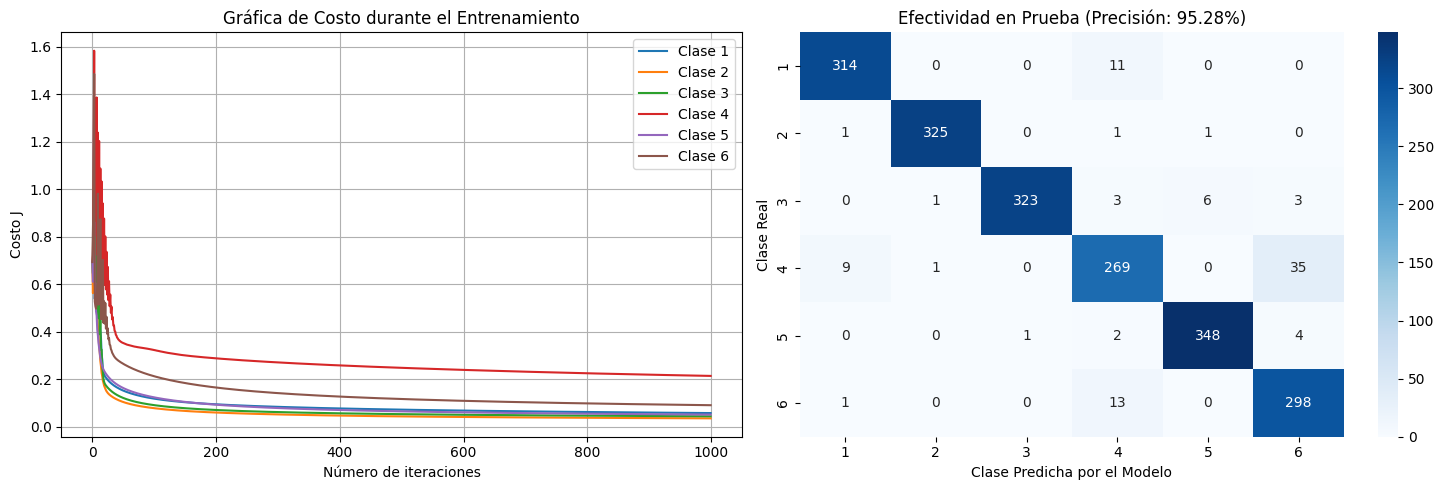

In [16]:
# 1. Función de Predicción
def predictOneVsAll(all_theta, X):
    m = X.shape[0]
    X = np.concatenate([np.ones((m, 1)), X], axis=1)

    # Calculamos la probabilidad de cada clase usando el sigmoide
    p = calcularSigmoide(np.dot(X, all_theta.T))

    # Retornamos el índice de la columna con la mayor probabilidad (+1 para que sea del 1 al 6)
    return np.argmax(p, axis=1) + 1

# 2. Hacemos las predicciones
pred_train = predictOneVsAll(all_theta, X_train_norm)
pred_test = predictOneVsAll(all_theta, X_test_norm)

# 3. Calculamos la Precisión
acc_train = np.mean(pred_train == y_train) * 100
acc_test = np.mean(pred_test == y_test) * 100

print(f"--- RESULTADOS DE PRECISIÓN ---")
print(f"Precisión en ENTRENAMIENTO (80% de datos): {acc_train:.2f}%")
print(f"Precisión en PRUEBA (20% de datos nuevos): {acc_test:.2f}%\n")

# 4. GRÁFICAS DE COSTO Y EFECTIVIDAD (Requisito del profesor)
plt.figure(figsize=(15, 5))

# Gráfica 1: Historial de Costo (Curva de Aprendizaje)
plt.subplot(1, 2, 1)
for i in range(num_labels):
    plt.plot(all_J_history[i], label=f'Clase {i+1}')
plt.title("Gráfica de Costo durante el Entrenamiento")
plt.xlabel("Número de iteraciones")
plt.ylabel("Costo J")
plt.legend()
plt.grid(True)

# Gráfica 2: Matriz de Confusión (Efectividad en el 20% de Prueba)
plt.subplot(1, 2, 2)
cm = confusion_matrix(y_test, pred_test)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=range(1, num_labels + 1),
            yticklabels=range(1, num_labels + 1))
plt.title(f"Efectividad en Prueba (Precisión: {acc_test:.2f}%)")
plt.xlabel("Clase Predicha por el Modelo")
plt.ylabel("Clase Real")

plt.tight_layout()
plt.show()

**DEMOSTRACION VISUAL MULTIMODAL Y HUELLA QUIMICA DE LOS GASES**

primero nos aseguramos de calcular las predicciones finales directamente ahi mismo para evitar cualquier error de memoria en tu cuaderno
luego usamos la herramienta random con una semilla fija para elegir tres ejemplos al azar de los datos de prueba asegurando que siempre  salgan exactamente los mismos graficos despues preparamos un lienzo gigante y abrimos un ciclo que va a iterar para dibujar una grafica por cada una de esas tres muestras
adentro de ese ciclo extraemos las ciento veintiocho caracteristicas que representan las lecturas de los ciento veintiocho sensores y las dibujamos trazando una linea y pintando el fondo para que parezca una onda de sonido de alta tecnologia
tambien le pusimos una logica inteligente al titulo para que se pinte de color verde y diga acierto si el modelo adivino correctamente o se ponga rojo si llega a fallar

lo mas importante de todo es que con este bloque explicamos y demostramos visualmente que el dataset es cien por ciento multimodal
decimos que es multimodal porque estamos fusionando y analizando multiples canales de informacion al mismo tiempo capturando distintos modos de comportamiento fisico y quimico a traves de la matriz de sensores
lo compruebas facilmente al ver la grafica porque notas que los sensores reaccionan de formas completamente diferentes creando patrones unicos para cada clase
por un lado se puede ver que un tipo de gas genera un patron totalmente caotico irregular y lleno de picos al azar mientras que otro tipo de gas produce una respuesta super estructurada y repetitiva que parece una ola del mar
al visualizar esto pruebas que tu modelo matematico logro aprender a diferenciar estas complejas firmas quimicas superando por mucho a los tipicos proyectos que solo clasifican pixeles

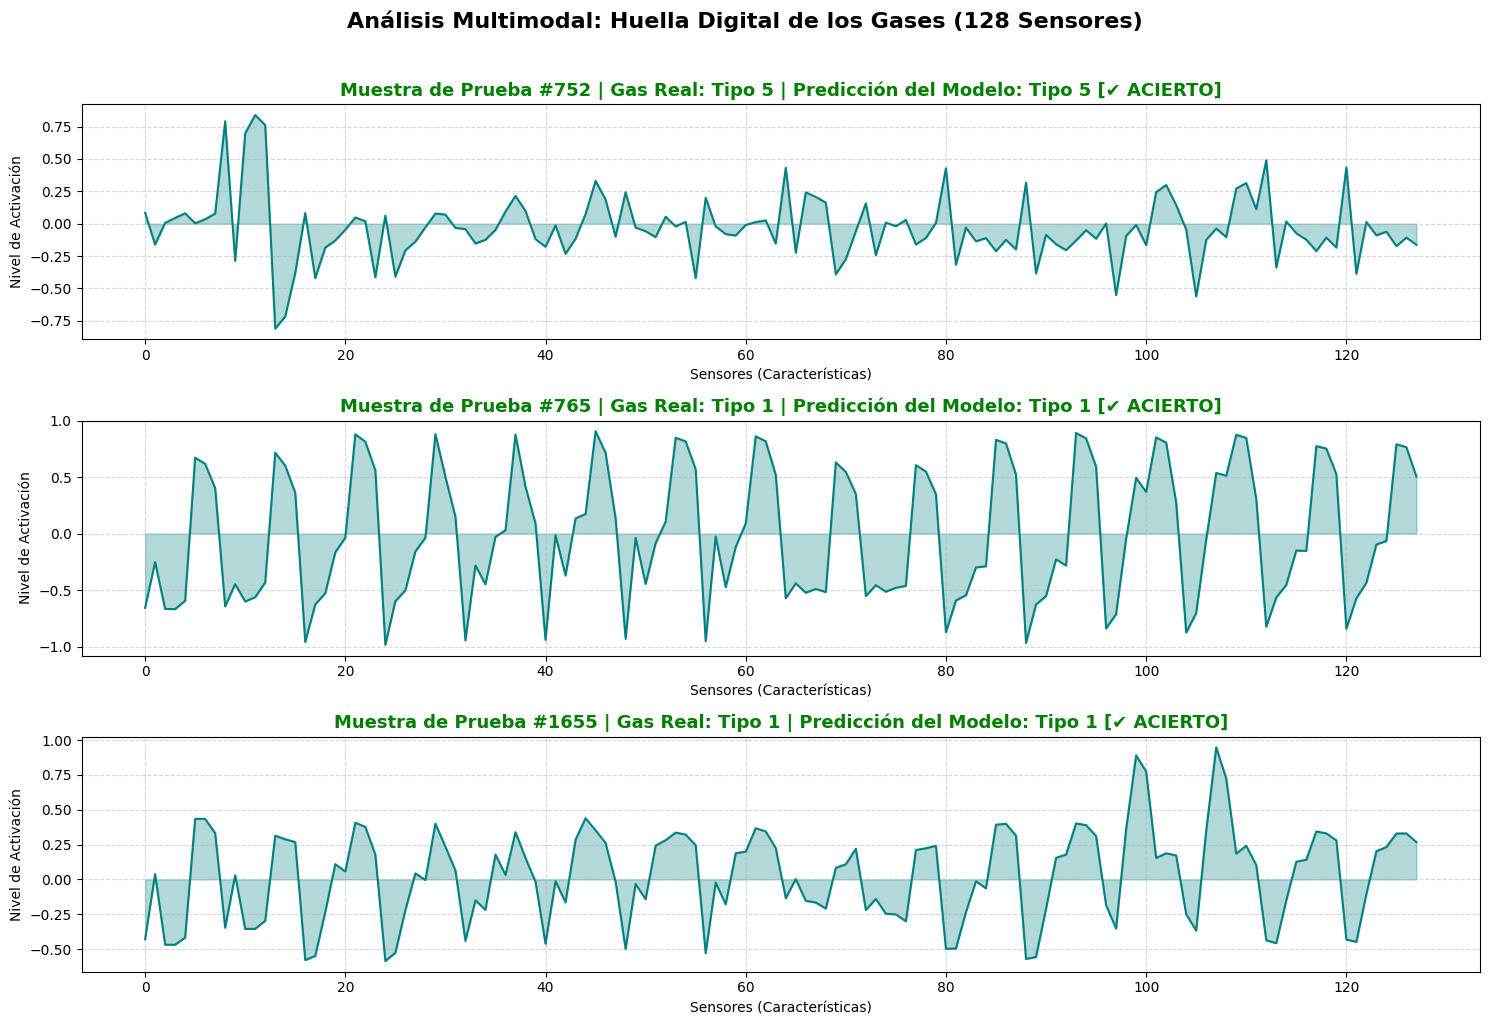

In [18]:
# 5. DEMOSTRACIÓN VISUAL DE LA "HUELLA QUÍMICA" DEL GAS

# --- SOLUCIÓN AL ERROR: Calculamos las predicciones aquí mismo ---
pred_test = predictOneVsAll(all_theta, X_test_norm)

# Tomamos 3 ejemplos aleatorios del conjunto de prueba
np.random.seed(42) # Para que siempre salgan los mismos ejemplos
indices_muestra = np.random.choice(len(X_test_norm), 3, replace=False)

plt.figure(figsize=(15, 10))
plt.suptitle("Análisis Multimodal: Huella Digital de los Gases (128 Sensores)", fontsize=16, fontweight='bold', y=1.02)

for i, idx in enumerate(indices_muestra):
    plt.subplot(3, 1, i + 1)

    # Extraemos las características del gas
    huella_gas = X_test_norm[idx]
    clase_real = int(y_test[idx])
    clase_predicha = int(pred_test[idx])

    # Graficamos la huella digital (el patrón de los sensores)
    plt.plot(huella_gas, color='teal', linewidth=1.5)
    plt.fill_between(range(len(huella_gas)), huella_gas, color='teal', alpha=0.3)

    # Título dinámico que cambia de color si el modelo acierta o falla
    if clase_real == clase_predicha:
        color_texto = 'green'
        resultado = "✔ ACIERTO"
    else:
        color_texto = 'red'
        resultado = "✖ FALLO"

    plt.title(f"Muestra de Prueba #{idx} | Gas Real: Tipo {clase_real} | Predicción del Modelo: Tipo {clase_predicha} [{resultado}]",
              color=color_texto, fontweight='bold', fontsize=13)

    plt.xlabel("Sensores (Características)", fontsize=10)
    plt.ylabel("Nivel de Activación", fontsize=10)
    plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()